# Exploratory Data Analysis

This notebook documents the initial exploration of the credit card transaction dataset. My objective is to assess data quality, identify key features correlated with fraudulent activity, and establish the technical requirements for the subsequent modelling phase.

### Summary of Insights

* **Data Health:** Confirmed zero missing values across all features; no immediate data entry errors were identified.
* **Class Imbalance:** Extreme skew (0.17% fraud) indicates that standard accuracy is an invalid metric. I will utilise Precision-Recall curves and AUPRC for evaluation.
* **Feature Relationships:** Latent features such as V17 and V14 show distinct separations between classes, making them strong candidates for model training.
* **Amount Distribution:** The 'Amount' feature is heavily skewed and contains $0.00 "ping" transactions, necessitating robust scaling or log transformation to normalise the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualisations
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
# Path adjusted to the new repository structure
data = pd.read_csv('../data/creditcard.csv')
num_rows, num_cols = data.shape

print(f"The dataset contains {num_rows:,} rows and {num_cols} columns.")

# Integrity Check
null_counts = data.isnull().sum().sum()
if null_counts == 0:
    print("Data Integrity Verified: No missing values found across 31 columns.")
else:
    print(f"Warning: {null_counts} missing values detected.")

The dataset contains 284,807 rows and 31 columns.
Data Integrity Verified: No missing values found across 31 columns.


## Class Distribution Analysis

It is established that the `Class` column is the response variable (label), where `1` represents a fraudulent transaction and `0` represents a genuine one.

Genuine Transactions: 284,315
Fraudulent Transactions: 492
Fraud Ratio: 0.1727%


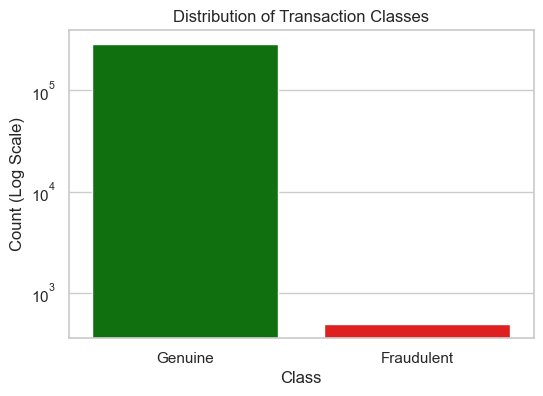

In [3]:
class_counts = data['Class'].value_counts()
fraud_ratio = class_counts[1] / len(data)

print(f"Genuine Transactions: {class_counts[0]:,}")
print(f"Fraudulent Transactions: {class_counts[1]:,}")
print(f"Fraud Ratio: {fraud_ratio:.4%}")

# Visualising the imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Class', data=data, palette=['green', 'red'], hue='Class', legend=False)
plt.title('Distribution of Transaction Classes')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')

# Rename X-axis ticks from 0, 1 to Genuine, Fraudulent
ax.set_xticks([0, 1])
ax.set_xticklabels(['Genuine', 'Fraudulent'])
plt.show()

## Feature Correlation

I will now examine which latent features (V1-V28) correlate most strongly with fraudulent activity to guide feature selection.

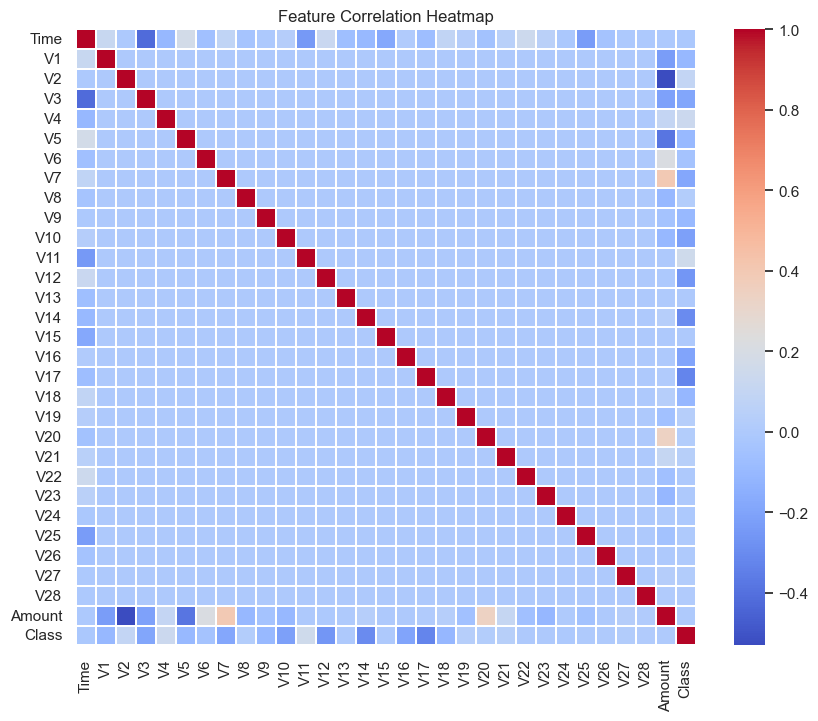

,Correlation
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


In [4]:
# Calculate correlation matrix
corr = data.corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title('Feature Correlation Heatmap')
plt.show()

# Extract top 10 influential features
# We sort by absolute value but display the original correlation values
abs_sorter = corr['Class'].abs().sort_values(ascending=False).index
influential_features = corr.loc[abs_sorter, ['Class']].drop('Class')

influential_features.columns = ['Correlation']
influential_features.head(10)

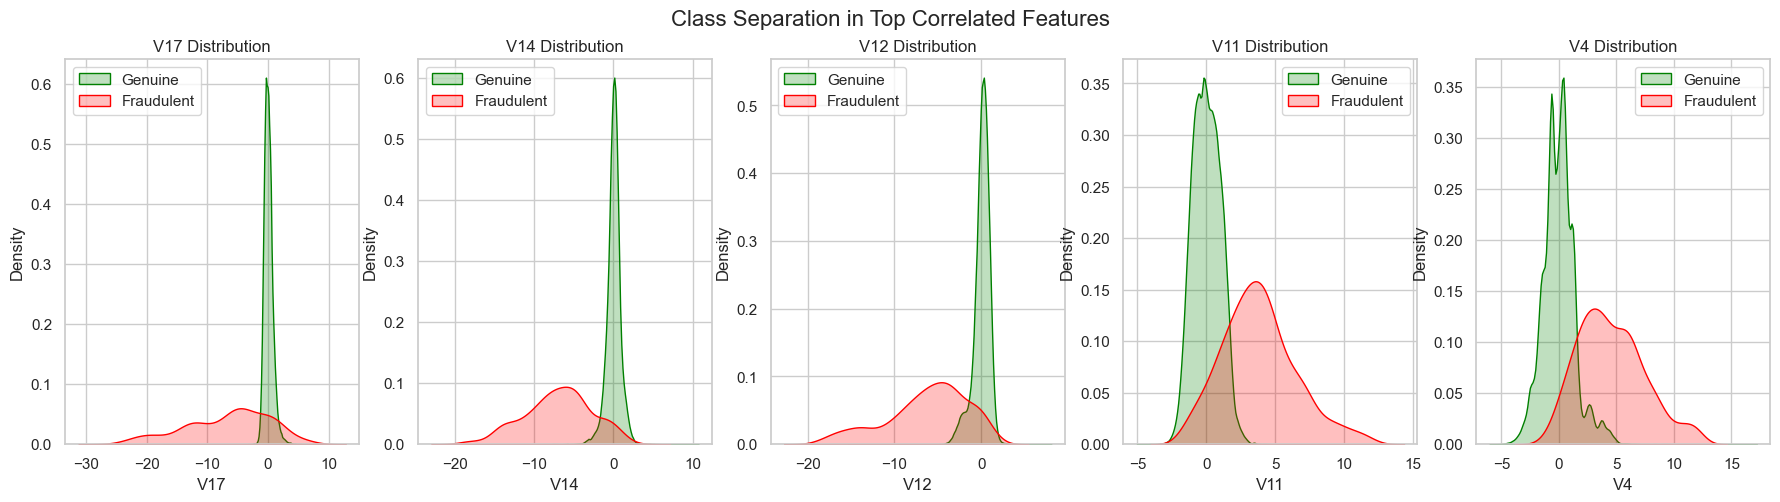

In [5]:
# Visualising distributions for top correlated features
top_features = ['V17', 'V14', 'V12', 'V11', 'V4']

fig, axes = plt.subplots(1, len(top_features), figsize=(22, 5))

for i, feature in enumerate(top_features):
    sns.kdeplot(data=data[data['Class'] == 0], x=feature, ax=axes[i], label='Genuine', fill=True, color='green')
    sns.kdeplot(data=data[data['Class'] == 1], x=feature, ax=axes[i], label='Fraudulent', fill=True, color='red')
    axes[i].set_title(f'{feature} Distribution')
    axes[i].legend()

plt.suptitle('Class Separation in Top Correlated Features', fontsize=16)
plt.show()

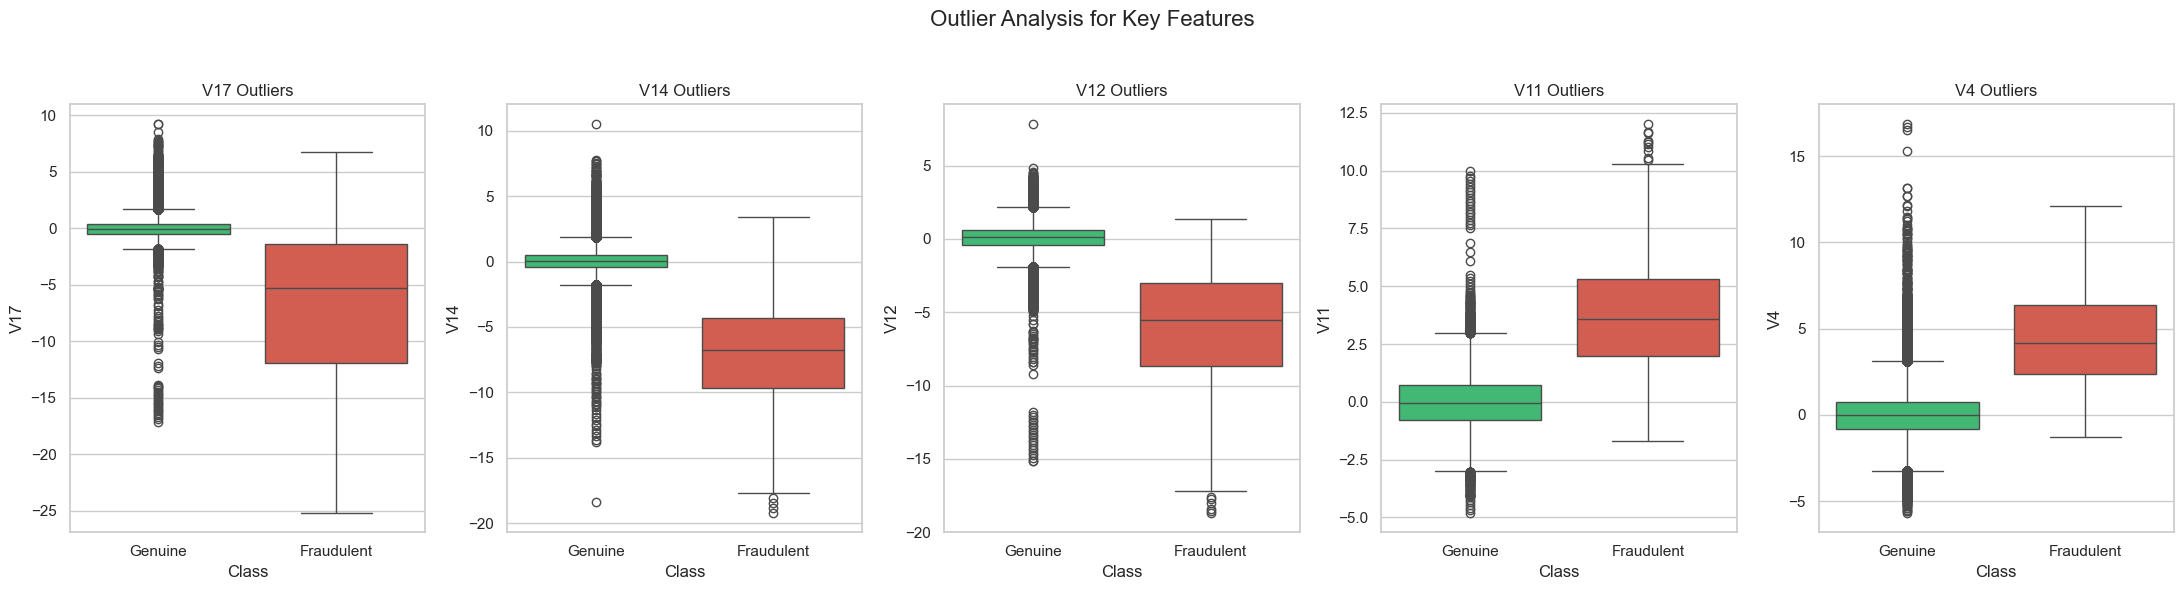

In [6]:
# Outlier Analysis
fig, axes = plt.subplots(1, len(top_features), figsize=(22, 6))

for i, feature in enumerate(top_features):
    sns.boxplot(x='Class', y=feature, data=data, palette=['#2ecc71', '#e74c3c'], ax=axes[i], hue='Class', legend=False)
    axes[i].set_title(f'{feature} Outliers')
    
    # Fixed Locator/Ticks to avoid UserWarning
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Genuine', 'Fraudulent'])

plt.suptitle('Outlier Analysis for Key Features', fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Temporal and Financial Features

The `Time` and `Amount` features require specific attention. `Time` is transformed into a cyclical `Hour` feature, while `Amount` is examined for its distribution and "ping" transactions ($0.00).

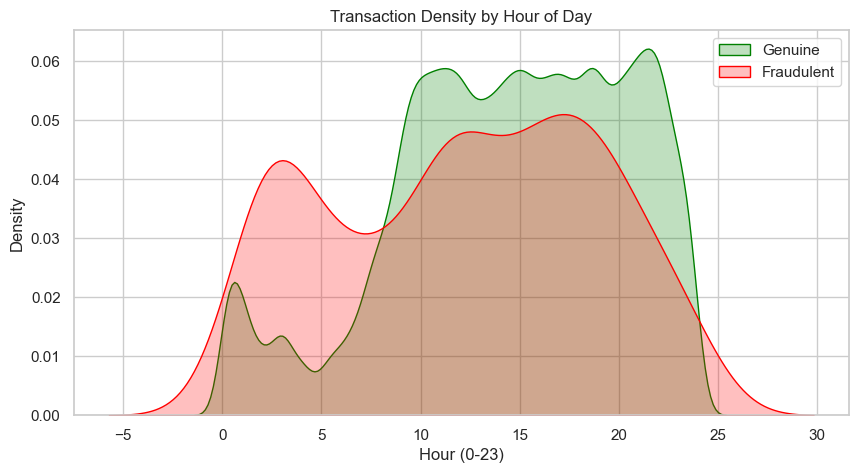

In [7]:
# Time Analysis
data['Hour'] = (data['Time'] / 3600) % 24

plt.figure(figsize=(10, 5))
sns.kdeplot(x=data[data['Class'] == 0]['Hour'], label='Genuine', fill=True, color='green')
sns.kdeplot(x=data[data['Class'] == 1]['Hour'], label='Fraudulent', fill=True, color='red')
plt.title('Transaction Density by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.legend()
plt.show()

,Amount
count,"284,807"
mean,$88.35
std,250.12
min,$0.00
25%,$5.60
50%,$22.00
75%,$77.16
max,"$25,691.16"


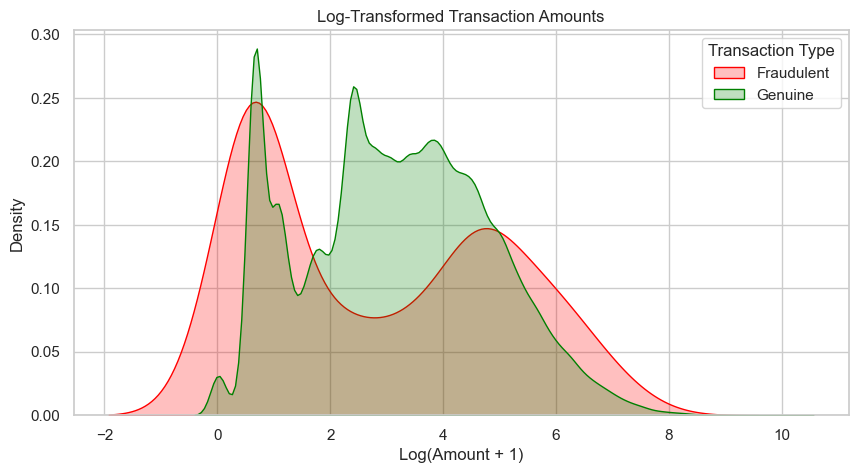

In [8]:
# Amount Analysis
desc_amt = data['Amount'].describe().to_frame()

formats = {
    'count': "{:,.0f}",
    'mean': "${:,.2f}",
    'std': "{:,.2f}",
    'min': "${:,.2f}",
    '25%': "${:,.2f}",
    '50%': "${:,.2f}",
    '75%': "${:,.2f}",
    'max': "${:,.2f}"
}

styled_df = pd.DataFrame(
    { 'Amount': [formats[str(idx)].format(val) for idx, val in desc_amt['Amount'].items()] },
    index=desc_amt.index
)

display(styled_df)

# Log-transformation to handle skewness
data['Log_Amount'] = np.log1p(data['Amount'])

plt.figure(figsize=(10, 5))
# Using the mapping to ensure colours and labels align correctly
ax = sns.kdeplot(data=data, x='Log_Amount', hue='Class', fill=True, common_norm=False, palette={0: 'green', 1: 'red'})

plt.title('Log-Transformed Transaction Amounts')
plt.xlabel('Log(Amount + 1)')
# Manually fixing legend to match the names
plt.legend(title='Transaction Type', labels=['Fraudulent', 'Genuine']) 
plt.show()

## Summary of Exploratory Data Analysis and Technical Implications

The initial exploration of the dataset has provided several critical insights that directly inform my modelling strategy:

1. **Extreme Class Imbalance:** With fraud representing only 0.17% of transactions, standard accuracy is a deceptive metric. My evaluation must prioritise the **Precision-Recall Curve** and **AUPRC** (Area Under the Precision-Recall Curve) over the ROC curve to ensure I am truly measuring the model's ability to detect the minority class.

2. **Feature Separation:** Visualising the top correlated features (V17, V14, V12) through KDE plots shows clear, distinct distributions for fraudulent versus genuine activity. This suggests that tree-based ensembles (Random Forest, XGBoost) should perform well by identifying these non-linear boundaries.

3. **Data Scaling and Outliers:** The `Amount` and `Time` features exhibit significant skew and include extreme values (such as $0.00 "ping" transactions). To prevent these from disproportionately influencing the model, I have opted for a **RobustScaler** within the training pipeline. Unlike standard scaling, this uses the interquartile range, making it resilient to the financial outliers characteristic of fraudulent behaviour.

4. **Temporal Patterns:** Converting the raw `Time` signal into a cyclical `Hour` feature reveals that fraud does not follow the typical "human" diurnal patterns of genuine cardholders, providing a high-value signal for the classifiers.

**Conclusion:** The production pipeline will utilise a **Stratified Split** to maintain class ratios and an **imblearn Pipeline** to ensure that scaling and resampling occur strictly within each cross-validation fold, thereby preventing any data leakage.